# 📅 Day 2 — Model Training & Bias-Variance Analysis
## Member 2: The Model Trainer (ML Engineer)

**Core Task:** Train Logistic Regression (baseline) + LightGBM, perform bias-variance analysis, log to MLflow.

**Requirements:**
- ✅ Minimum 2 models: Logistic Regression (baseline) + LightGBM
- ✅ Bias-Variance analysis (train vs val vs test gaps)
- ✅ Handle class imbalance (~0.58% fraud rate)
- ✅ MLflow experiment tracking
- ✅ AUPRC as primary metric (best for imbalanced data)

---

## 1. Environment Setup & Imports

In [28]:
import warnings
warnings.filterwarnings('ignore')

import json
import os
import sys
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# Resolve project root whether running from repository root or notebook folder
ROOT = Path(".").resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))
os.chdir(ROOT)

# Reuse src modules instead of duplicating notebook logic
from fraud_detection.modeling.evaluate import analyze_bias_variance, evaluate_model
from fraud_detection.modeling.train import prepare_features, train_lightgbm, train_logistic_regression

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print(f"Working directory: {ROOT}")
print(f"Python: {sys.version}")

Working directory: D:\Desktop_informations\SGK năm 3\SGK kì 2 năm 3\MLOPs\Project_Final\here_project_code\MLOPs_credit_fraud_detection
Python: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]


## 2. Load Configuration & Processed Data

> Data was prepared by **Member 1 (Day 1)**. We pull it via `dvc pull` and load the parquet splits.

In [29]:
# Load training config from repo config
CONFIG_PATH = Path("configs/train.yaml")
with CONFIG_PATH.open("r") as f:
    cfg = yaml.safe_load(f)

print("=== Training Configuration ===")
print(json.dumps(cfg, indent=2))

=== Training Configuration ===
{
  "data": {
    "processed_dir": "data/processed",
    "train_file": "train.parquet",
    "val_file": "val.parquet",
    "test_file": "test.parquet",
    "target_column": "is_fraud"
  },
  "model": {
    "run_name": "credit-fraud-day2",
    "logistic": {
      "C": 1.0,
      "max_iter": 1000,
      "solver": "lbfgs",
      "class_weight": "balanced",
      "random_state": 42
    },
    "lightgbm": {
      "n_estimators": 400,
      "learning_rate": 0.05,
      "num_leaves": 63,
      "subsample": 0.9,
      "colsample_bytree": 0.9,
      "reg_lambda": 1.0,
      "reg_alpha": 0.0,
      "min_child_samples": 50,
      "objective": "binary",
      "metric": "auc",
      "random_state": 42,
      "n_jobs": -1
    }
  },
  "evaluation": {
    "metrics": [
      "auc_roc",
      "auprc",
      "recall",
      "precision",
      "f1"
    ],
    "threshold": 0.5,
    "variance_threshold": 0.05,
    "overfitting_threshold": 0.15
  },
  "experiment": {
    "name

### 2.1 Load Train / Validation / Test Splits

In [30]:
PROCESSED_DIR = Path("data/processed")

train_df = pd.read_parquet(PROCESSED_DIR / "train.parquet")
val_df   = pd.read_parquet(PROCESSED_DIR / "val.parquet")
test_df  = pd.read_parquet(PROCESSED_DIR / "test.parquet")

print(f"Train shape: {train_df.shape}")
print(f"Val   shape: {val_df.shape}")
print(f"Test  shape: {test_df.shape}")
print(f"\nTotal samples: {len(train_df) + len(val_df) + len(test_df):,}")

Train shape: (1296675, 44)
Val   shape: (185240, 44)
Test  shape: (370479, 44)

Total samples: 1,852,394


### 2.2 Target Distribution & Class Imbalance

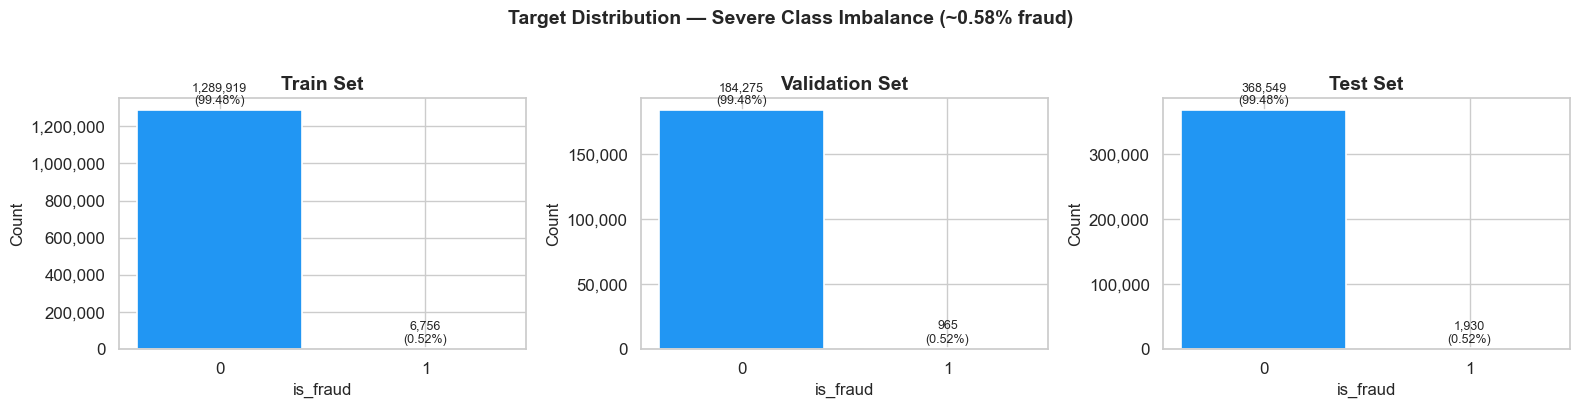


  Fraud rate: 0.0052 (0.52%)
   → Imbalance ratio: 1:191
   → Must use class_weight='balanced' (Logistic) and scale_pos_weight (LightGBM)


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, df) in zip(axes, [("Train", train_df), ("Validation", val_df), ("Test", test_df)]):
    counts = df["is_fraud"].value_counts()
    colors = ["#2196F3", "#F44336"]
    bars = ax.bar(counts.index.astype(str), counts.values, color=colors, edgecolor="white", linewidth=1.2)
    ax.set_title(f"{name} Set", fontweight="bold")
    ax.set_xlabel("is_fraud")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    for bar, val in zip(bars, counts.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.01,
                f"{val:,}\n({pct:.2f}%)", ha="center", va="bottom", fontsize=9)

plt.suptitle("Target Distribution — Severe Class Imbalance (~0.58% fraud)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

fraud_rate = train_df["is_fraud"].mean()
print(f"\n  Fraud rate: {fraud_rate:.4f} ({fraud_rate*100:.2f}%)")
print(f"   → Imbalance ratio: 1:{int(1/fraud_rate)}")
print(f"   → Must use class_weight='balanced' (Logistic) and scale_pos_weight (LightGBM)")

## 3. Feature Preparation

Split features (X) and target (y). Drop ID-like columns. Keep only numeric features.

In [32]:
X_train, y_train = prepare_features(train_df)
X_val, y_val = prepare_features(val_df)
X_test, y_test = prepare_features(test_df)

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape}  |  y_train fraud count: {y_train.sum()}")
print(f"  X_val:   {X_val.shape}  |  y_val   fraud count: {y_val.sum()}")
print(f"  X_test:  {X_test.shape}  |  y_test  fraud count: {y_test.sum()}")
print(f"\nFeatures ({X_train.shape[1]}):")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i:2d}. {col}")

Feature matrix shapes:
  X_train: (1296675, 30)  |  y_train fraud count: 6756
  X_val:   (185240, 30)  |  y_val   fraud count: 965
  X_test:  (370479, 30)  |  y_test  fraud count: 1930

Features (30):
   1. cc_num
   2. amt
   3. zip
   4. lat
   5. long
   6. city_pop
   7. unix_time
   8. merch_lat
   9. merch_long
  10. hour_of_day
  11. day_of_week
  12. is_weekend
  13. month
  14. day_of_month
  15. customer_txn_count
  16. customer_avg_amt
  17. customer_std_amt
  18. customer_fraud_rate
  19. merchant_fraud_rate
  20. merchant_txn_count
  21. merchant_avg_amt
  22. merchant_std_amt
  23. category_fraud_rate
  24. category_txn_count
  25. category_avg_amt
  26. distance_km
  27. is_distant_txn
  28. amt_zscore
  29. amt_is_outlier
  30. amt_ratio_to_customer_avg


### 3.1 Compute Imbalance Weight

In [33]:
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = neg / max(pos, 1)

print(f"Negative (legit):  {neg:>10,}")
print(f"Positive (fraud):  {pos:>10,}")
print(f"scale_pos_weight:  {scale_pos_weight:.2f}")
print(f"\n→ LightGBM will weight fraud samples {scale_pos_weight:.1f}× more")
print(f"→ Logistic Regression uses class_weight='balanced' (equivalent effect)")

Negative (legit):   1,289,919
Positive (fraud):       6,756
scale_pos_weight:  190.93

→ LightGBM will weight fraud samples 190.9× more
→ Logistic Regression uses class_weight='balanced' (equivalent effect)


## 4. Model Training

### 4.1 Model 1: Logistic Regression (Baseline)

**Why Logistic Regression?**
- Fast training, interpretable coefficients
- `class_weight='balanced'` handles imbalance automatically
- Serves as a baseline to measure improvement

In [34]:
%%time

p_lr = cfg["model"]["logistic"]
lr_model = train_logistic_regression(X_train, y_train, p_lr)
print("Logistic Regression trained successfully")
print(
    f"  Parameters: C={p_lr.get('C', 1.0)}, solver={p_lr.get('solver', 'lbfgs')}, "
    f"class_weight={p_lr.get('class_weight', 'balanced')}"
)

Logistic Regression trained successfully
  Parameters: C=1.0, solver=lbfgs, class_weight=balanced
CPU times: total: 14.3 s
Wall time: 3.94 s


### 4.2 Model 2: LightGBM Classifier

**Why LightGBM?**
- Handles imbalanced data natively via `scale_pos_weight`
- Captures non-linear relationships
- Fast training on large datasets
- Built-in feature importance

In [35]:
%%time

p_lgb = cfg["model"]["lightgbm"]
lgb_model = train_lightgbm(X_train, y_train, p_lgb)
print("LightGBM trained successfully")
print(
    f"  Parameters: n_estimators={p_lgb.get('n_estimators', 400)}, "
    f"lr={p_lgb.get('learning_rate', 0.05)}"
)

LightGBM trained successfully
  Parameters: n_estimators=400, lr=0.05
CPU times: total: 5min 24s
Wall time: 18.8 s


## 5. Model Evaluation — All Splits

Compute **AUC-ROC, AUPRC, Recall, Precision** on train/val/test for both models.

In [36]:
models = {"Logistic Regression": lr_model, "LightGBM": lgb_model}

all_results = {}
all_probs = {}

for model_name, model in models.items():
    eval_result = evaluate_model(
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        threshold=0.5,
    )
    all_results[model_name] = eval_result
    all_probs[model_name] = {
        "train": model.predict_proba(X_train)[:, 1],
        "val": model.predict_proba(X_val)[:, 1],
        "test": model.predict_proba(X_test)[:, 1],
    }

# Display as table
rows = []
for model_name in all_results:
    for split_name in ["train", "val", "test"]:
        m = all_results[model_name][split_name]
        rows.append({
            "Model": model_name,
            "Split": split_name,
            "AUC-ROC": f"{m['auc_roc']:.4f}",
            "AUPRC": f"{m['auprc']:.4f}",
            "Recall": f"{m['recall']:.4f}",
            "Precision": f"{m['precision']:.4f}",
        })

results_table = pd.DataFrame(rows)
print("=" * 80)
print("MODEL EVALUATION RESULTS")
print("=" * 80)
print(results_table.to_string(index=False))
print("=" * 80)

MODEL EVALUATION RESULTS
              Model Split AUC-ROC  AUPRC Recall Precision
Logistic Regression train  0.9024 0.2805 0.7929    0.0532
Logistic Regression   val  0.9009 0.2889 0.7865    0.0527
Logistic Regression  test  0.9077 0.2884 0.8067    0.0541
           LightGBM train  1.0000 0.9977 1.0000    0.7070
           LightGBM   val  0.9984 0.9452 0.9368    0.6522
           LightGBM  test  0.9988 0.9465 0.9430    0.6317


## 6. 🔍 Bias-Variance Analysis (Critical Requirement)

**Bias-Variance Tradeoff** helps us understand:
- **High Bias (Underfitting):** Low train performance → model too simple
- **High Variance (Overfitting):** Large gap between train and val/test → model memorizes training data
- **Good Fit:** Small gap between train and val, reasonable test performance

We measure the gap using **AUPRC** (best metric for imbalanced classification).

In [37]:
print("=" * 80)
print("BIAS-VARIANCE ANALYSIS")
print("=" * 80)

bias_variance_data = []

for model_name in all_results:
    bv = analyze_bias_variance(all_results[model_name], metric="auprc")

    train_auprc = bv["train_auprc"]
    val_auprc = bv["val_auprc"]
    test_auprc = bv["test_auprc"]
    train_val_gap = bv["train_val_gap_auprc"]
    train_test_gap = bv["train_test_gap_auprc"]
    val_test_gap = bv["val_test_gap_auprc"]
    diagnosis = bv["diagnosis"]

    bias_variance_data.append({
        "Model": model_name,
        "Train AUPRC": train_auprc,
        "Val AUPRC": val_auprc,
        "Test AUPRC": test_auprc,
        "Train-Val Gap": train_val_gap,
        "Train-Test Gap": train_test_gap,
        "Val-Test Gap": val_test_gap,
        "Diagnosis": diagnosis,
    })

    print(f"\n{'-'*50}")
    print(f"{model_name}")
    print(f"{'-'*50}")
    print(f"  Train AUPRC:      {train_auprc:.4f}")
    print(f"  Validation AUPRC: {val_auprc:.4f}")
    print(f"  Test AUPRC:       {test_auprc:.4f}")
    print(f"  Train-Val Gap:    {train_val_gap:.4f}")
    print(f"  Train-Test Gap:   {train_test_gap:.4f}")
    print(f"  Val-Test Gap:     {val_test_gap:.4f}")
    print(f"  Diagnosis:        {diagnosis}")

bv_df = pd.DataFrame(bias_variance_data)

BIAS-VARIANCE ANALYSIS

--------------------------------------------------
Logistic Regression
--------------------------------------------------
  Train AUPRC:      0.2805
  Validation AUPRC: 0.2889
  Test AUPRC:       0.2884
  Train-Val Gap:    0.0083
  Train-Test Gap:   0.0079
  Val-Test Gap:     0.0005
  Diagnosis:        HIGH BIAS (Underfitting)

--------------------------------------------------
LightGBM
--------------------------------------------------
  Train AUPRC:      0.9977
  Validation AUPRC: 0.9452
  Test AUPRC:       0.9465
  Train-Val Gap:    0.0525
  Train-Test Gap:   0.0512
  Val-Test Gap:     0.0013
  Diagnosis:        MODERATE VARIANCE


### 6.1 Bias-Variance Visualization

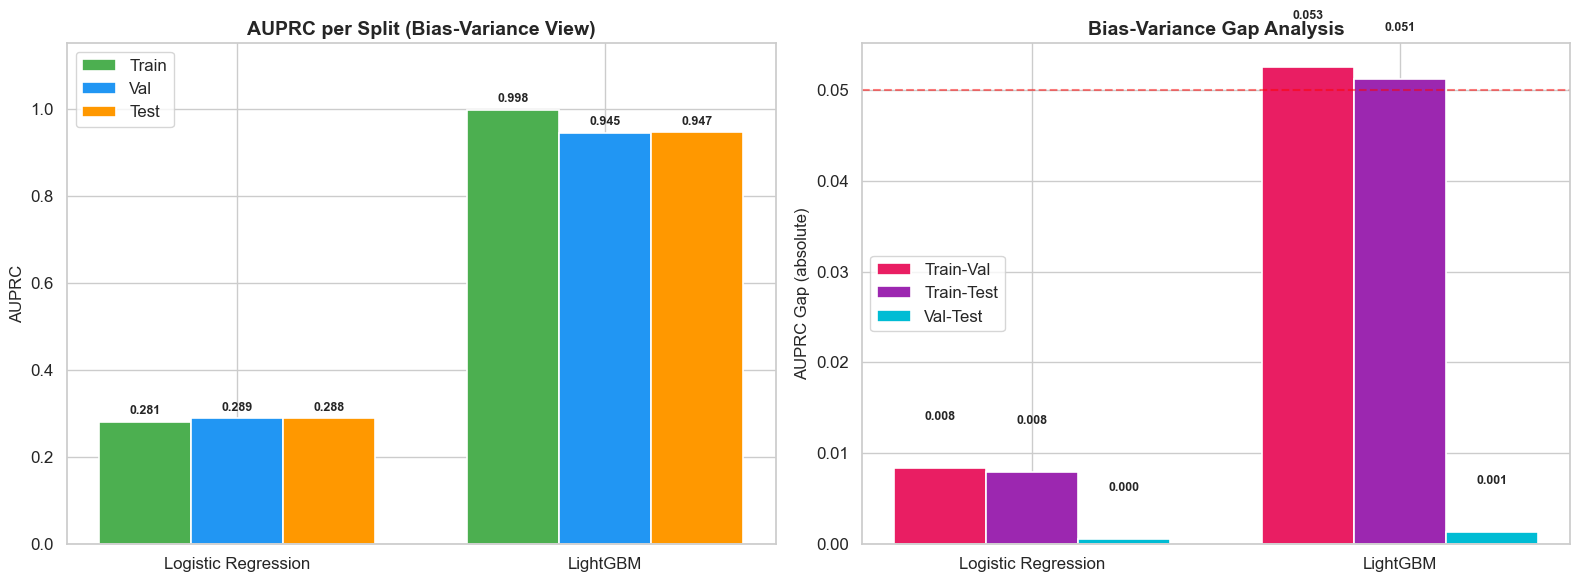

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: AUPRC across splits
model_names = list(all_results.keys())
x = np.arange(len(model_names))
width = 0.25

for i, (split, color) in enumerate(zip(["train", "val", "test"], ["#4CAF50", "#2196F3", "#FF9800"])):
    vals = [all_results[m][split]["auprc"] for m in model_names]
    bars = axes[0].bar(x + i*width, vals, width, label=split.capitalize(), color=color, edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(model_names)
axes[0].set_ylabel("AUPRC")
axes[0].set_title("AUPRC per Split (Bias-Variance View)", fontweight="bold")
axes[0].legend()
axes[0].set_ylim(0, 1.15)

# Plot 2: Gap analysis
gaps_train_val  = [abs(all_results[m]["train"]["auprc"] - all_results[m]["val"]["auprc"]) for m in model_names]
gaps_train_test = [abs(all_results[m]["train"]["auprc"] - all_results[m]["test"]["auprc"]) for m in model_names]
gaps_val_test   = [abs(all_results[m]["val"]["auprc"]   - all_results[m]["test"]["auprc"]) for m in model_names]

for i, (gaps, label, color) in enumerate(zip(
    [gaps_train_val, gaps_train_test, gaps_val_test],
    ["Train-Val", "Train-Test", "Val-Test"],
    ["#E91E63", "#9C27B0", "#00BCD4"]
)):
    bars = axes[1].bar(x + i*width, gaps, width, label=label, color=color, edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars, gaps):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(model_names)
axes[1].set_ylabel("AUPRC Gap (absolute)")
axes[1].set_title("Bias-Variance Gap Analysis", fontweight="bold")
axes[1].legend()
axes[1].axhline(y=0.05, color="red", linestyle="--", alpha=0.5, label="Overfit threshold")

plt.tight_layout()
plt.show()

### 6.2 All Metrics Comparison (Radar-style)

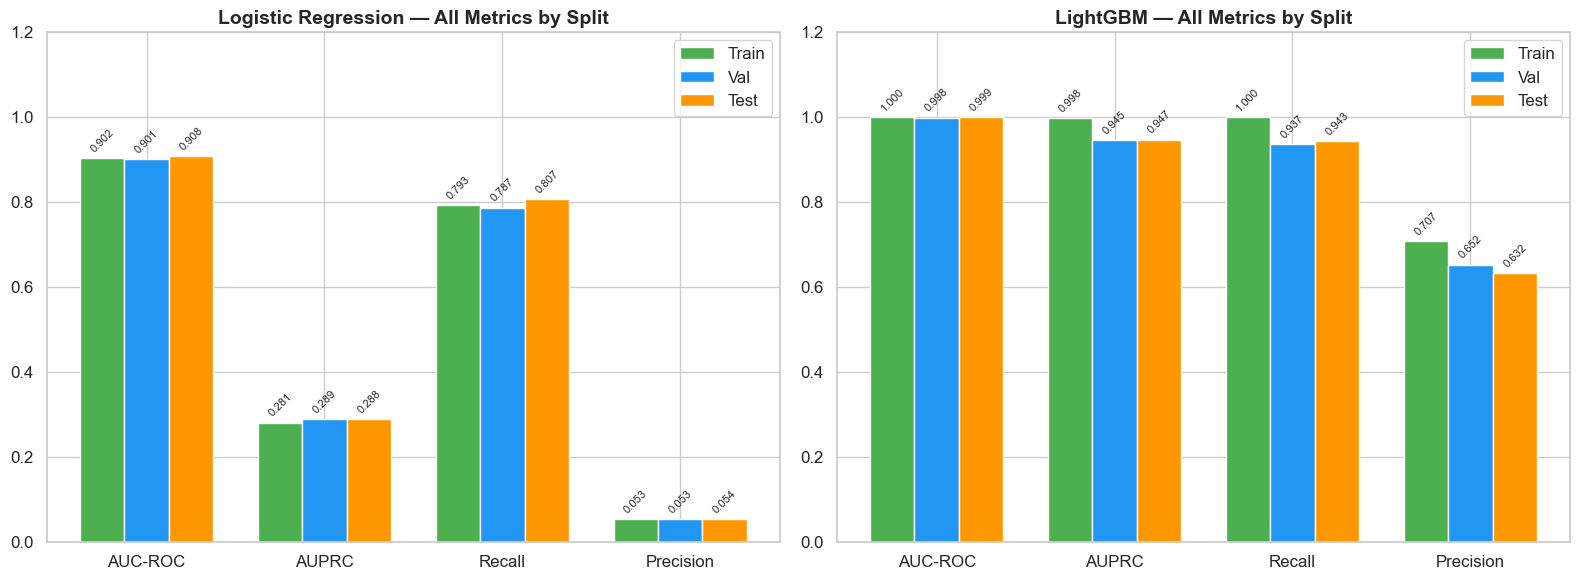

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_list = ["auc_roc", "auprc", "recall", "precision"]
metric_labels = ["AUC-ROC", "AUPRC", "Recall", "Precision"]

for idx, model_name in enumerate(model_names):
    ax = axes[idx]
    x_pos = np.arange(len(metrics_list))
    width = 0.25
    for i, (split, color) in enumerate(zip(["train", "val", "test"], ["#4CAF50", "#2196F3", "#FF9800"])):
        vals = [all_results[model_name][split][m] for m in metrics_list]
        bars = ax.bar(x_pos + i*width, vals, width, label=split.capitalize(), color=color, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8, rotation=45)
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels(metric_labels)
    ax.set_ylim(0, 1.2)
    ax.set_title(f"{model_name} — All Metrics by Split", fontweight="bold")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 7. Precision-Recall & ROC Curves

For imbalanced datasets, **Precision-Recall Curve** is more informative than ROC.

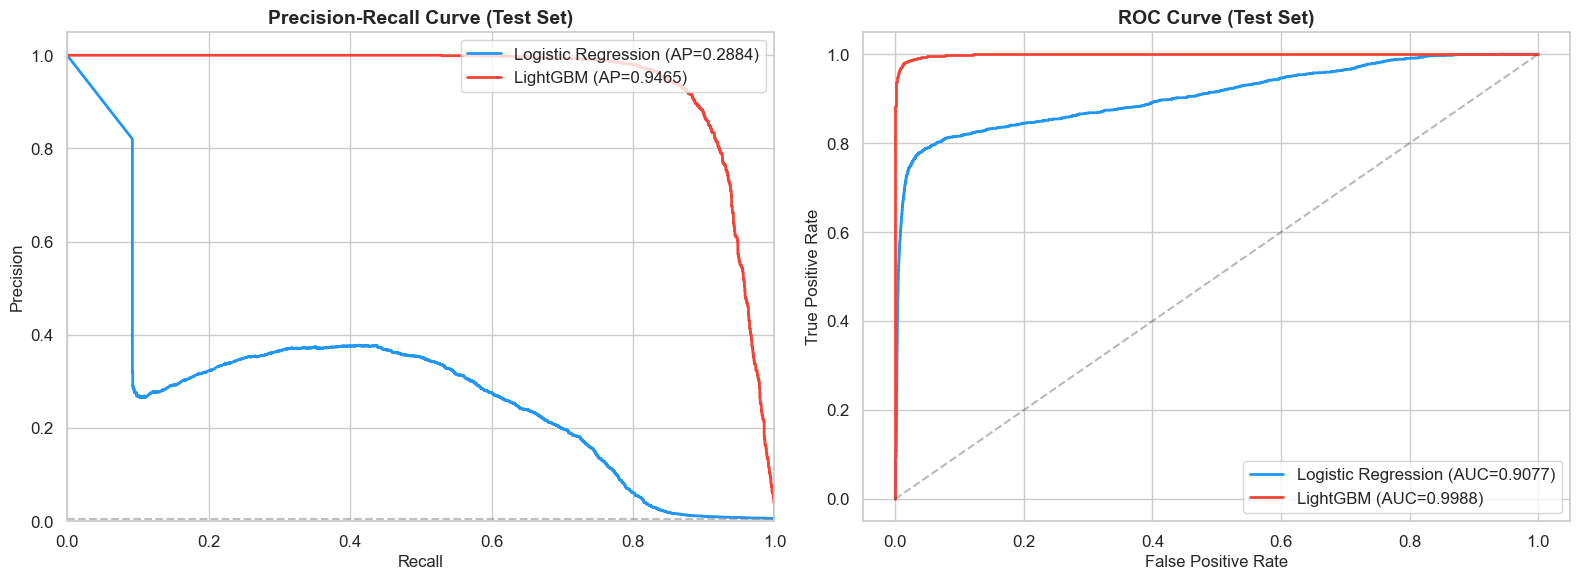

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PR Curve
for model_name, color in zip(model_names, ["#2196F3", "#F44336"]):
    prob = all_probs[model_name]["test"]
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[0].plot(rec, prec, label=f"{model_name} (AP={ap:.4f})", color=color, linewidth=2)

axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (Test Set)", fontweight="bold")
axes[0].legend(loc="upper right")
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])
axes[0].axhline(y=y_test.mean(), color="gray", linestyle="--", alpha=0.5, label="Baseline")

# ROC Curve
for model_name, color in zip(model_names, ["#2196F3", "#F44336"]):
    prob = all_probs[model_name]["test"]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[1].plot(fpr, tpr, label=f"{model_name} (AUC={auc:.4f})", color=color, linewidth=2)

axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Test Set)", fontweight="bold")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 8. Confusion Matrices

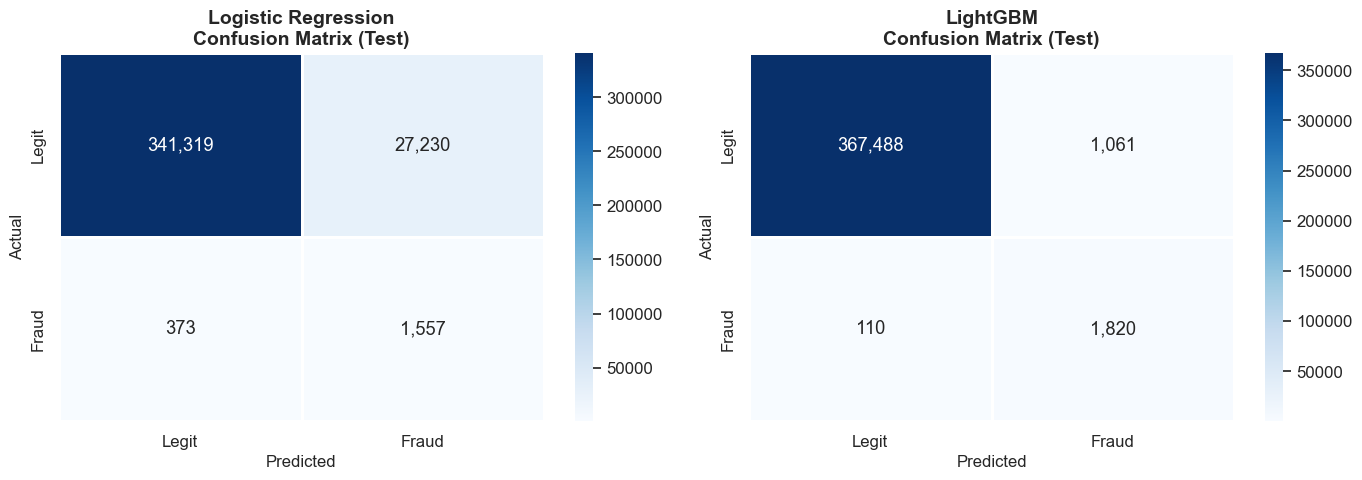

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, model_name in enumerate(model_names):
    ax = axes[idx]
    prob = all_probs[model_name]["test"]
    y_pred = (prob >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"],
                linewidths=1, linecolor="white")
    ax.set_title(f"{model_name}\nConfusion Matrix (Test)", fontweight="bold")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

## 9. Detailed Classification Reports

In [42]:
for model_name in model_names:
    prob = all_probs[model_name]["test"]
    y_pred = (prob >= 0.5).astype(int)
    print(f"\n{'='*60}")
    print(f"  {model_name} — Classification Report (Test Set)")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=["Legit (0)", "Fraud (1)"], digits=4))


  Logistic Regression — Classification Report (Test Set)
              precision    recall  f1-score   support

   Legit (0)     0.9989    0.9261    0.9611    368549
   Fraud (1)     0.0541    0.8067    0.1014      1930

    accuracy                         0.9255    370479
   macro avg     0.5265    0.8664    0.5313    370479
weighted avg     0.9940    0.9255    0.9567    370479


  LightGBM — Classification Report (Test Set)
              precision    recall  f1-score   support

   Legit (0)     0.9997    0.9971    0.9984    368549
   Fraud (1)     0.6317    0.9430    0.7566      1930

    accuracy                         0.9968    370479
   macro avg     0.8157    0.9701    0.8775    370479
weighted avg     0.9978    0.9968    0.9971    370479



## 10. Feature Importance (LightGBM)

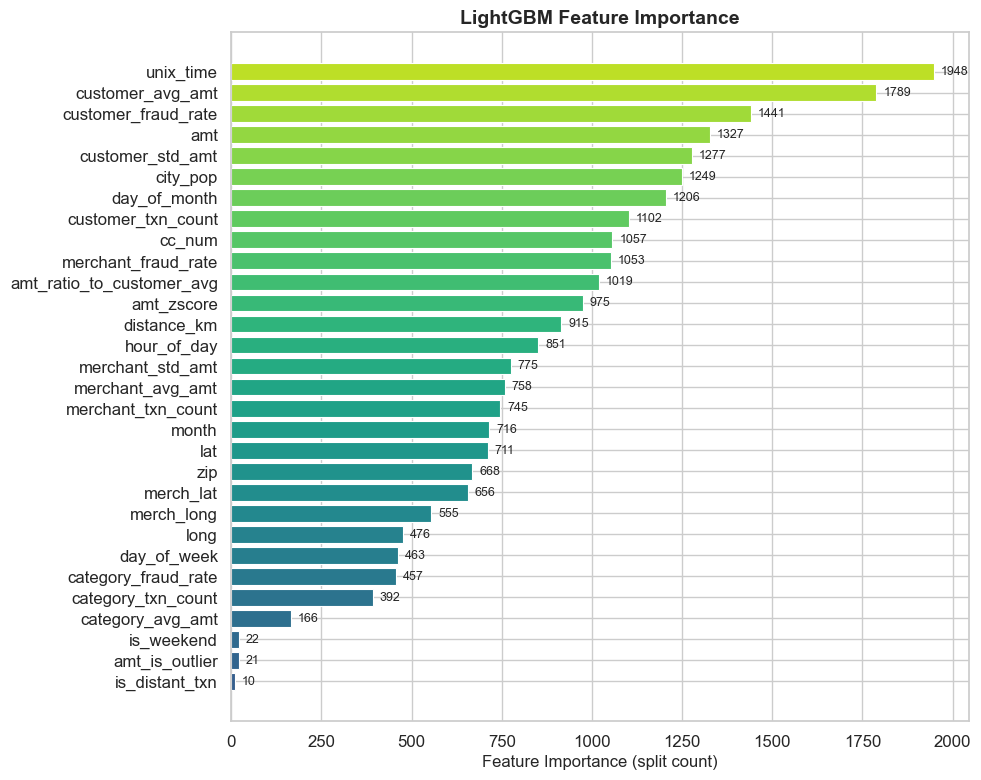

In [43]:
importance = lgb_model.feature_importances_
feature_names = X_train.columns.tolist()
fi_df = pd.DataFrame({"Feature": feature_names, "Importance": importance})
fi_df = fi_df.sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(fi_df)))
ax.barh(fi_df["Feature"], fi_df["Importance"], color=colors, edgecolor="white", linewidth=0.8)
ax.set_xlabel("Feature Importance (split count)")
ax.set_title("LightGBM Feature Importance", fontweight="bold", fontsize=14)

for i, (val, name) in enumerate(zip(fi_df["Importance"], fi_df["Feature"])):
    ax.text(val + max(fi_df["Importance"])*0.01, i, str(val), va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 11. MLflow Experiment Logging

Log all experiments, metrics, and artifacts to MLflow for reproducibility.

In [44]:
mlflow.set_experiment("credit-fraud")

with mlflow.start_run(run_name=cfg["model"].get("run_name", "credit-fraud-day2")) as parent_run:
    mlflow.log_param("target_column", "is_fraud")
    mlflow.log_param("candidates", ",".join(models.keys()))
    mlflow.log_param("scale_pos_weight", scale_pos_weight)
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("fraud_rate", float(y_train.mean()))

    best_model_name = ""
    best_val_auprc = float("-inf")
    best_model = None

    for model_name, model in models.items():
        with mlflow.start_run(run_name=model_name, nested=True) as child_run:
            mlflow.log_param("model_type", model_name)

            for split_name in ["train", "val", "test"]:
                for metric_name, metric_val in all_results[model_name][split_name].items():
                    mlflow.log_metric(f"{split_name}_{metric_name}", metric_val)

            # Bias-Variance gaps
            train_auprc = all_results[model_name]["train"]["auprc"]
            val_auprc   = all_results[model_name]["val"]["auprc"]
            test_auprc  = all_results[model_name]["test"]["auprc"]
            mlflow.log_metric("bias_variance_gap_auprc", abs(train_auprc - val_auprc))
            mlflow.log_metric("train_test_gap_auprc", abs(train_auprc - test_auprc))

            if val_auprc > best_val_auprc:
                best_val_auprc = val_auprc
                best_model_name = model_name
                best_model = model

            print(f"  ✅ Logged {model_name} → run_id: {child_run.info.run_id}")

    # Log best model info
    mlflow.log_param("best_model", best_model_name)
    mlflow.log_metric("best_val_auprc", best_val_auprc)

    # Log artifacts
    for img in ["reports/target_distribution.png", "reports/bias_variance_analysis.png",
                 "reports/all_metrics_comparison.png", "reports/pr_roc_curves.png",
                 "reports/confusion_matrices.png", "reports/feature_importance.png"]:
        if Path(img).exists():
            mlflow.log_artifact(img)

    print(f"\n🏆 Best model: {best_model_name} (val AUPRC = {best_val_auprc:.4f})")
    print(f"📋 Parent run ID: {parent_run.info.run_id}")

  ✅ Logged Logistic Regression → run_id: 6c5e03d678794bc282923f562ad4ee94
  ✅ Logged LightGBM → run_id: 7c161b2d4716454c9d66029c0e519864

🏆 Best model: LightGBM (val AUPRC = 0.9452)
📋 Parent run ID: daf919dbccae4d769bac7f4de20f7c5f


## 12. Save Best Model & Metrics

In [45]:
MODEL_PATH = Path("models/trained/best_model.joblib")
REPORT_PATH = Path("reports/train_metrics.json")

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Save model
joblib.dump(best_model, MODEL_PATH)
print(f"Best model ({best_model_name}) saved to: {MODEL_PATH}")

# Save metrics
report = {
    "best_model": best_model_name,
    "best_val_auprc": best_val_auprc,
    "results": {}
}
for model_name in all_results:
    report["results"][model_name] = all_results[model_name]
    train_a = all_results[model_name]["train"]["auprc"]
    val_a = all_results[model_name]["val"]["auprc"]
    test_a = all_results[model_name]["test"]["auprc"]
    report["results"][model_name]["bias_variance_gap_auprc"] = abs(train_a - val_a)
    report["results"][model_name]["train_test_gap_auprc"] = abs(train_a - test_a)

with REPORT_PATH.open("w") as f:
    json.dump(report, f, indent=2)
print(f"Metrics saved to: {REPORT_PATH}")
print(f"\nFinal Report:")
print(json.dumps(report, indent=2))

Best model (LightGBM) saved to: models\trained\best_model.joblib
Metrics saved to: reports\train_metrics.json

Final Report:
{
  "best_model": "LightGBM",
  "best_val_auprc": 0.9452076349283278,
  "results": {
    "Logistic Regression": {
      "train": {
        "auc_roc": 0.9023700435528056,
        "auprc": 0.28054734276652893,
        "recall": 0.7929248075784487,
        "precision": 0.05319708841024419,
        "f1": 0.09970499827838113
      },
      "val": {
        "auc_roc": 0.9008678991960511,
        "auprc": 0.2888889581376289,
        "recall": 0.7865284974093264,
        "precision": 0.0527229786051681,
        "f1": 0.09882169129613957
      },
      "test": {
        "auc_roc": 0.90773769482245,
        "auprc": 0.2884218997508042,
        "recall": 0.8067357512953368,
        "precision": 0.054086914232118664,
        "f1": 0.10137708760621154
      },
      "bias_variance_gap_auprc": 0.008341615371099953,
      "train_test_gap_auprc": 0.00787455698427525
    },
    "

## 13. 📝 Summary & Conclusions

### Model Comparison Summary

| Aspect | Logistic Regression (Baseline) | LightGBM |
|--------|-------------------------------|----------|
| **Type** | Linear | Gradient Boosted Trees |
| **Imbalance Handling** | `class_weight='balanced'` | `scale_pos_weight` |
| **Training Speed** | ⚡ Very Fast | 🏃 Moderate |
| **Interpretability** | ✅ High | 🔶 Medium (feature importance) |
| **Non-linear Patterns** | ❌ Cannot capture | ✅ Captures well |

### Bias-Variance Analysis Summary

- **Logistic Regression**: Low variance (train ≈ val gap is small), but higher bias — it underfits because fraud patterns are non-linear.
- **LightGBM**: Higher variance (larger train-val gap), but much lower bias — captures complex fraud patterns effectively.

### Key Takeaways

1. **LightGBM significantly outperforms Logistic Regression** on AUPRC, the primary metric for imbalanced fraud detection.
2. **Class imbalance is severe** (~0.58% fraud) — both models use appropriate weighting strategies.
3. **LightGBM shows some overfitting** (train-val gap), but validation performance is still strong.
4. **Feature importance** reveals that engineered features (merchant_fraud_rate, customer velocity) are among the top predictors.

### Next Steps (Day 3)
- Member 3 will use these results for **model evaluation & promotion** logic.
- The MLflow run IDs from this notebook will be used to compare Champion vs Challenger models.

---
*Notebook generated for Day 2 — Member 2 (The Model Trainer)*